# Практическая 4 (Саттаров Булат Рамилевич ЭФМО-01-25)

## Задание
Реализовать расчеты способами а и б для набора данных из файла insclass_train.csv/
Для 151 406 договоров страхования транспортных средств известны значения ряда признаков, в том числе пол, возраст, стаж вождения и коэффициент бонус-малус водителя, тип, марка, модель, год выпуска, страна – производитель, мощность и объем двигателя, а также признак target, равный 1, если заключение договора с клиентом является рисковым, и 0 в противном случае (файл insclass_train.csv).

Требуется построить модель, предсказывающую значение признака target для 22 624 договоров из тестового набора данных (файл insclass_test.csv).

In [55]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [56]:
# Загрузка данных
df = pd.read_csv('insclass_train.csv')
print('Размер данных:', df.shape)
df.head()

Размер данных: (151406, 29)


,variable_1,variable_2,variable_3,variable_4,variable_5,variable_6,variable_7,variable_8,variable_9,variable_10,...,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,target
0,w200,0,0,14,q2,98.0,NaN,0.0,NaN,0,...,C,j2,h45,0,0.0,0,1,19.323463,t1,0
1,w160,0,0,7,q11,106.0,NaN,0.0,NaN,0,...,C,j33,h234,0,1.0,0,1,41.177900,t1,0
2,w200,0,0,4,q3,123.0,NaN,0.0,NaN,0,...,B,j12,h28,0,0.0,0,1,3.614395,t1,0
3,w200,0,0,9,q3,102.0,NaN,0.0,NaN,0,...,C,j12,h64,0,1.0,0,0,49.041674,t1,0
4,w200,0,0,18,q20,117.0,NaN,0.0,NaN,0,...,C,j111,h991,0,1.0,0,0,17.909612,t1,0


In [57]:
# Проверка пропусков
df.isna().sum().sort_values(ascending=False).head(10)

variable_15    151393
variable_9     134436
variable_7      95639
variable_8      29899
variable_14      2927
variable_24      2207
variable_27      2067
variable_13      1657
variable_12      1528
variable_6        111
dtype: int64

## Подготовка данных

In [58]:
X = df.drop(columns=['target']).copy()
Y = df['target'].astype(int).copy()

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [col for col in X.columns if col not in numeric_cols]

# Заполнение пропусков
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

X = pd.get_dummies(X, drop_first=True)


In [59]:
x_train, x_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


In [60]:
mu = x_train.mean(axis=0)
sigma = x_train.std(axis=0)
sigma[sigma == 0] = 1

x_train = (x_train - mu) / sigma
x_test = (x_test - mu) / sigma

x_train = x_train.to_numpy(dtype=float)
x_test = x_test.to_numpy(dtype=float)
Y_train = Y_train.to_numpy(dtype=float).reshape(-1, 1)
Y_test = Y_test.to_numpy(dtype=float).reshape(-1, 1)

x_train = np.hstack([np.ones((x_train.shape[0], 1)), x_train])
x_test = np.hstack([np.ones((x_test.shape[0], 1)), x_test])

print(x_train.shape, x_test.shape)

(121124, 1746) (30282, 1746)


In [61]:
class LogisticRegressionGD(object):
    def __init__(self):
        self.a = None
        
    def sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))
    
    def predict(self, x):
        return self.sigmoid(x @ self.a)
    
    def predict_class(self, x):
        return (self.predict(x) > 0.5).astype(int)
    
    def coefs(self):
        return self.a
      
    def LogLikelihood(self, p, Y):
        p = np.clip(p, 1e-12, 1 - 1e-12)
        return (Y * np.log(p) + (1 - Y) * np.log(1 - p)).mean()

    def CrossEntropy(self, p, Y):
        p = np.clip(p, 1e-12, 1 - 1e-12)
        return (-Y * np.log(p) - (1 - Y) * np.log(1 - p)).mean()
    
    def accuracy(self, x, Y):
        return (self.predict_class(x) == Y).mean()

    def fit(self, x, Y, alpha=0.01, epsylon=0.01, max_steps=1000, Rtype="LL"):
        self.a = np.zeros(x.shape[1]).reshape(x.shape[1], 1)
        steps, errors = [], []
        step = 0
        
        for _ in range(max_steps):
            p = self.predict(x)
            
            if Rtype == "LL":
                new_error = self.LogLikelihood(p, Y)
                dT_a = x.T @ (Y - p) / x.shape[0]
                self.a += alpha * dT_a

            elif Rtype == "CE":
                new_error = self.CrossEntropy(p, Y)
                dT_a = x.T @ (p - Y) / x.shape[0]
                self.a -= alpha * dT_a

            else:
                raise ValueError("Rtype должен быть 'LL' или 'CE'")
                
            step += 1
            steps.append(step)
            errors.append(new_error)
                
        return steps, errors

## Обучение модели способом а

In [62]:
alpha = 0.05
max_steps = 1000

model_LL = LogisticRegressionGD()
start_LL = time.time()
steps_LL, errors_LL = model_LL.fit(x_train, Y_train, alpha=alpha, max_steps=max_steps, Rtype='LL')
time_LL = time.time() - start_LL

pred_LL = model_LL.predict_class(x_test)
acc_LL = accuracy_score(Y_test, pred_LL)
f1_LL = f1_score(Y_test, pred_LL)

print('Время обучения:', round(time_LL, 4), 'сек')
print('Accuracy:', acc_LL)
print('F1:', f1_LL)
print('Матрица ошибок:')
print(confusion_matrix(Y_test, pred_LL))

Время обучения: 38.3764 сек
Accuracy: 0.9107390529027145
F1: 0.2005323868677906
Матрица ошибок:
[[27240   150]
 [ 2553   339]]


## Обучение модели способом б

In [63]:
model_CE = LogisticRegressionGD()
start_CE = time.time()
steps_CE, errors_CE = model_CE.fit(x_train, Y_train, alpha=alpha, max_steps=max_steps, Rtype='CE')
time_CE = time.time() - start_CE

pred_CE = model_CE.predict_class(x_test)
acc_CE = accuracy_score(Y_test, pred_CE)
f1_CE = f1_score(Y_test, pred_CE)

print('Время обучения:', round(time_CE, 4), 'сек')
print('Accuracy:', acc_CE)
print('F1:', f1_CE)
print('Матрица ошибок:')
print(confusion_matrix(Y_test, pred_CE))

Время обучения: 38.4575 сек
Accuracy: 0.9107390529027145
F1: 0.2005323868677906
Матрица ошибок:
[[27240   150]
 [ 2553   339]]


## Графики изменения

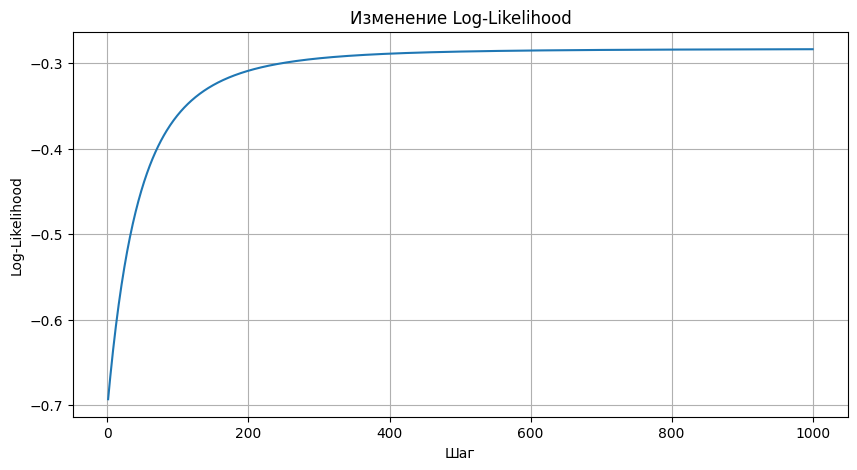

In [64]:
plt.figure(figsize=(10, 5))
plt.plot(steps_LL, errors_LL)
plt.title('Изменение Log-Likelihood')
plt.xlabel('Шаг')
plt.ylabel('Log-Likelihood')
plt.grid(True)
plt.show()

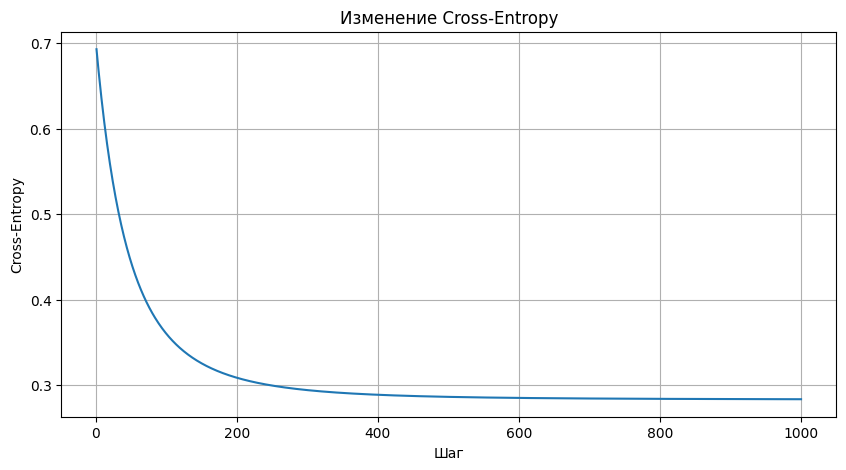

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(steps_CE, errors_CE)
plt.title('Изменение Cross-Entropy')
plt.xlabel('Шаг')
plt.ylabel('Cross-Entropy')
plt.grid(True)
plt.show()

## Сравнение результатов

In [66]:
results = pd.DataFrame({
    'Способ': ['а) Log-Likelihood', 'б) Cross-Entropy'],
    'alpha': [alpha, alpha],
    'max_steps': [max_steps, max_steps],
    'time_sec': [time_LL, time_CE],
    'accuracy': [acc_LL, acc_CE],
    'f1': [f1_LL, f1_CE]
})

results

,Способ,alpha,max_steps,time_sec,accuracy,f1
0,а) Log-Likelihood,0.05,1000,38.376410,0.910739,0.200532
1,б) Cross-Entropy,0.05,1000,38.457477,0.910739,0.200532


## Вывод

Были реализованы два способа обучения бинарной логистической регрессии. В первом случае выполнялась максимизация Log-Likelihood методом градиентного подъема. Во втором случае выполнялась минимизация Cross-Entropy методом градиентного спуска. Для обоих способов использовались одинаковые значения скорости обучения и числа шагов.

После обучения модели были сравнены по времени выполнения, accuracy и F1-мере на тестовой выборке, полученной делением исходного набора данных в пропорции 80/20. Результаты обоих подходов должны получаться близкими, так как минимизация Cross-Entropy эквивалентна максимизации Log-Likelihood с противоположным знаком функции.